<a href="https://colab.research.google.com/github/mftaa/Pengolahan_Citra/blob/main/jobsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Jobsheet 4 : Segmentasi Gambar
#Miftachussurur - 4.33.23.1.15

##Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

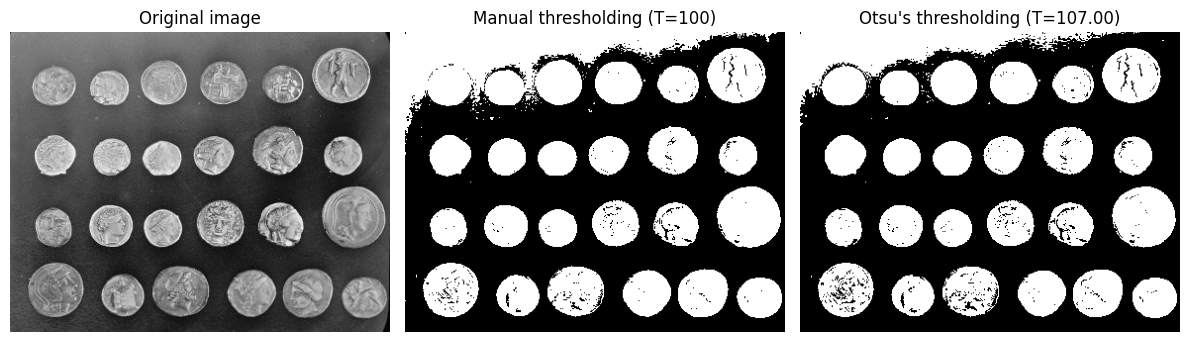

nilai thershold otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

image_coins = data.coins()

thresh_manual = 100
binary_manual = image_coins > thresh_manual

thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

fig, axes = plt.subplots( ncols=3, figsize=(12, 4))
ax= axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual thresholding (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s thresholding (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print(f'nilai thershold otsu yang ditemukan: {thresh_otsu}')

##Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

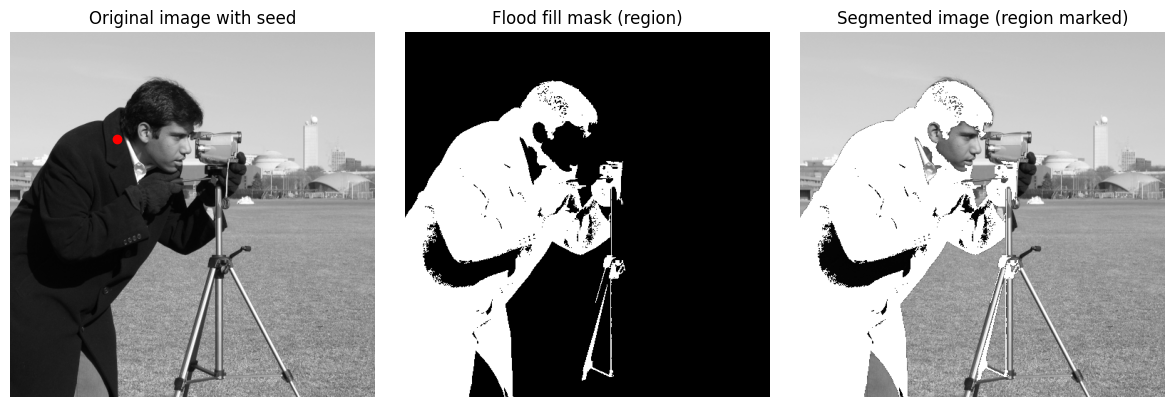

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color


image_camera = data.camera()

seed_point = (150,150)

flood_mask = segmentation.flood(image_camera, seed_point, tolerance=30)

segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original image with seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap= plt.cm.gray)
ax[1].set_title('Flood fill mask (region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented image (region marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

##Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

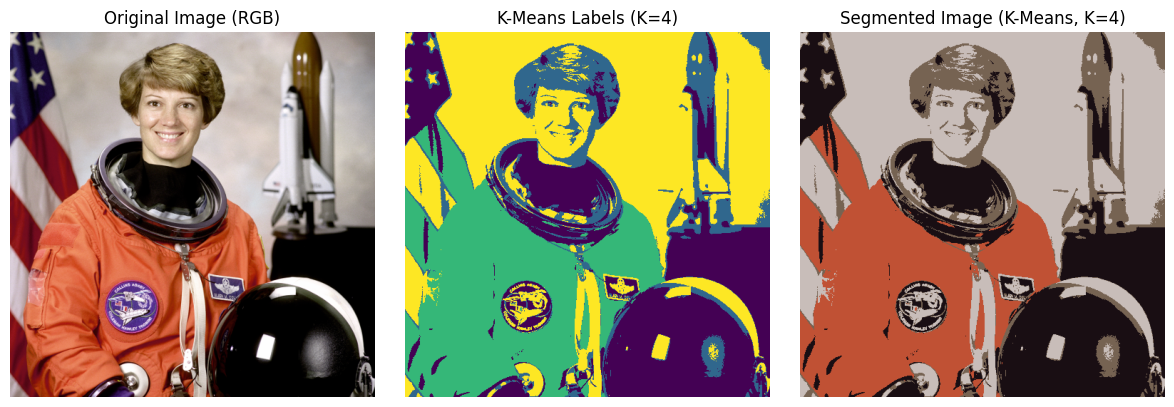

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

image_astro = data.astronaut()

image_astro_float = image_astro.astype(float) / 255.0

image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)

segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    cluster_pixels = (pixel_labels == k)
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

##Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

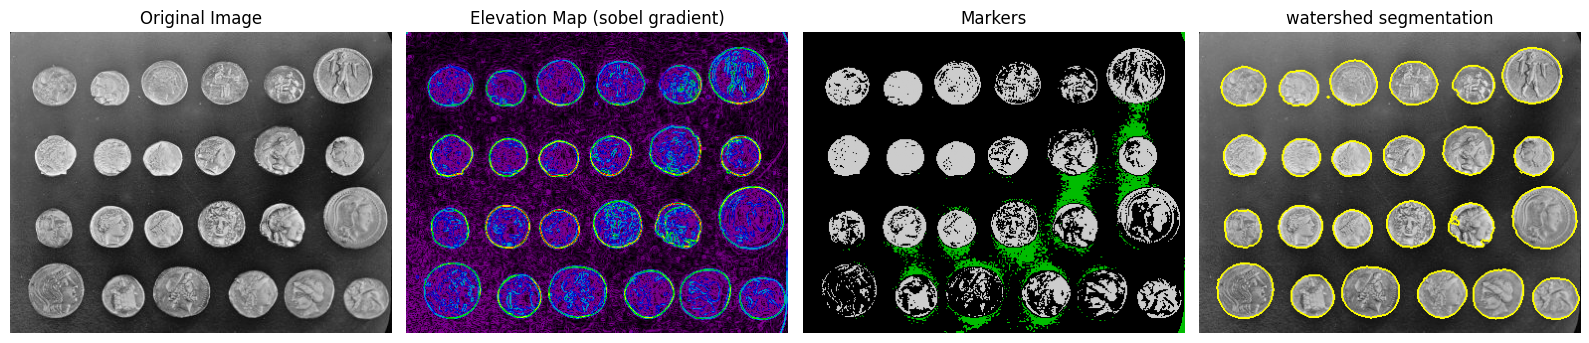

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters,segmentation, morphology, measure
from scipy import ndimage as ndimage

image_coins = data.coins()

elevation_map = filters.sobel(image_coins)

markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

segmentation_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (sobel gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmentation_colored)
ax[3].set_title('watershed segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

##Praktikum 5. Perbandingan Visual Hasil Segmentasi

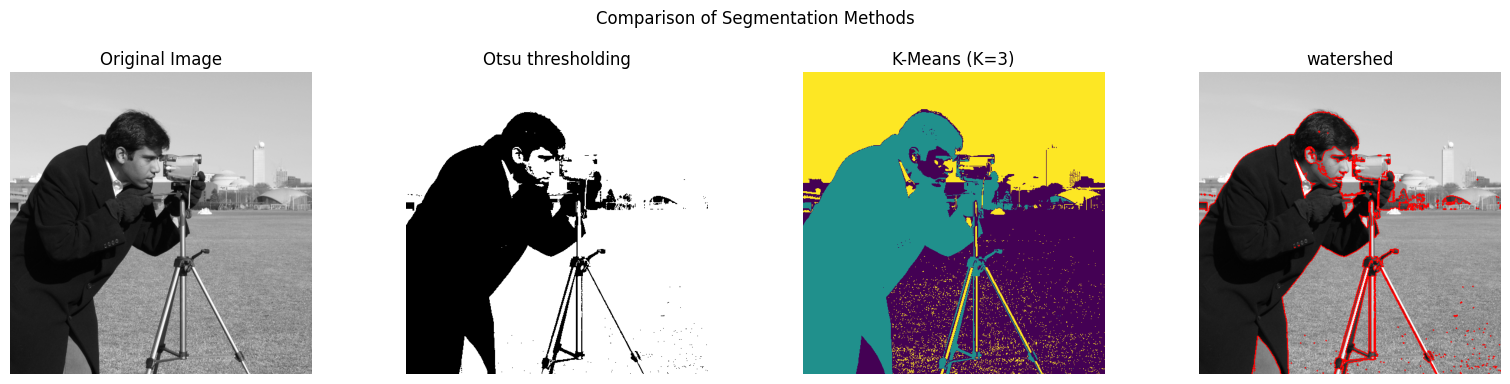

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters,segmentation, img_as_float,color
from sklearn.cluster import KMeans
import numpy as np
import warnings

image = data.camera()
image_float = img_as_float(image)

thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_label = pixel_labels.reshape(rows, cols)

elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

fig,axes = plt.subplots(1,4,figsize=(16, 4), sharex=True, sharey=True)
ax=axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_label, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0))
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##Penugasan Eksperimen Thresholding

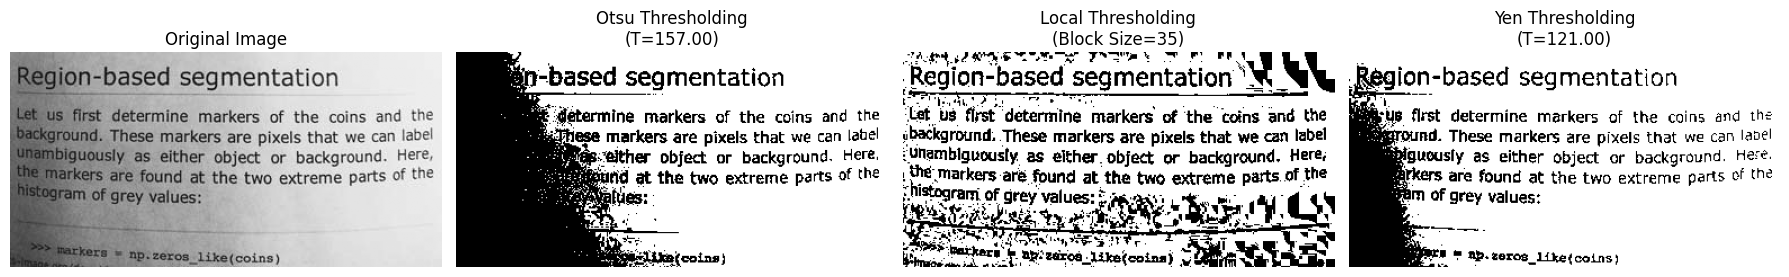

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

image_page = data.page()

thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

block_size = 35
binary_local = filters.threshold_local(image_page, block_size)
binary_local_result = image_page > binary_local

thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Thresholding\n(T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local_result, cmap=plt.cm.gray)
ax[2].set_title(f'Local Thresholding\n(Block Size={block_size})')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title(f'Yen Thresholding\n(T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()


##Penugasan Menggunakan Contoh citra lain

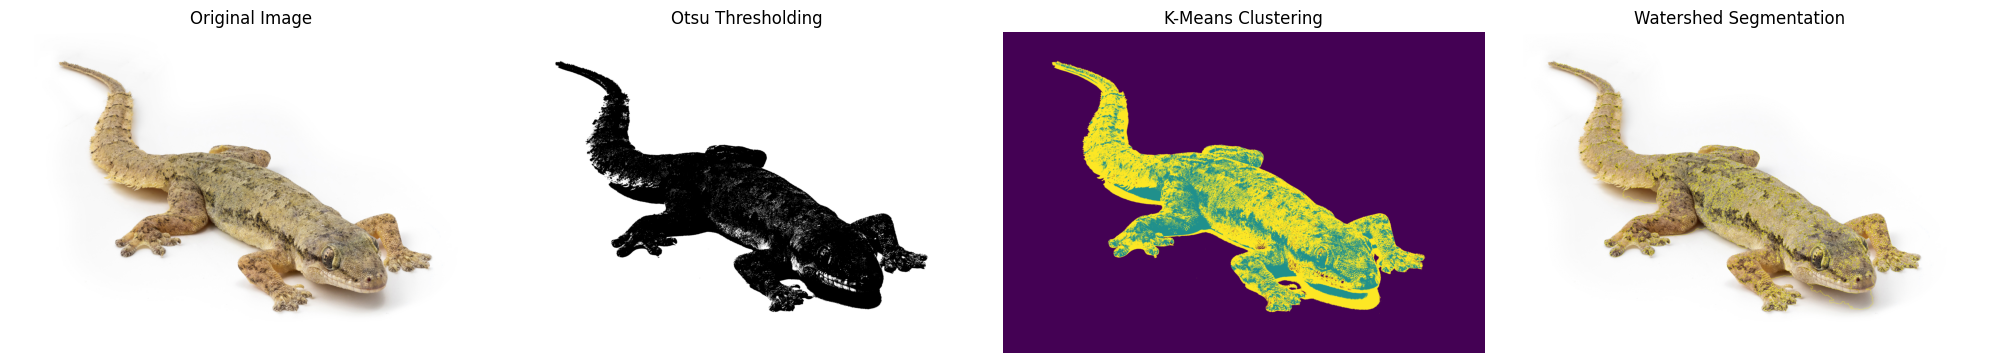

In [ ]:
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation, morphology
from sklearn.cluster import KMeans
import numpy as np
from scipy import ndimage as ndi

url = 'https://upload.wikimedia.org/wikipedia/commons/0/0a/Hemidactylus_platyurus_%28Flat-tailed_House_Gecko%29_on_white_background%2C_focus_stacking.jpg'
image = io.imread(url)
image_rgb = image[:, :, :3]

image_gray = color.rgb2gray(image_rgb)

thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

rows, cols, dims = image_rgb.shape
image_flat = image_rgb.reshape(rows * cols, dims)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans.fit(image_flat)
labels = kmeans.labels_.reshape(rows, cols)

elevation_map = filters.sobel(image_gray)
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < 0.4] = 1
markers[image_gray > 0.8] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmentation_colored = segmentation.mark_boundaries(image_rgb, segmentation_watershed)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image_rgb)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(labels, cmap='viridis')
ax[2].set_title('K-Means Clustering')
ax[2].axis('off')

ax[3].imshow(segmentation_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()
